# 124: Kmerseek False-Positive Ortholog Characterization

Characterizes pairs that Kmerseek calls significant (conservative Bonferroni p < 0.05
over all N_HUMAN × N_MOUSE comparisons) **but are NOT true MGI orthologs** — i.e., false
positives.

The same conservative threshold used in notebook 120 is applied here. Shared data-loading
and annotation code lives in `ortholog_analysis_utils.py`.

**Sets**
| Label | Definition |
|---|---|
| `false_positives` | `kmerseek_pred & ~is_mgi_ortholog` |
| `true_positives` | `kmerseek_pred & is_mgi_ortholog` |
| `background` | OrthoFinder TPs (same as nb 120) |

**Analyses**
1. Score distributions — Jaccard, containment, enrichment, Poisson p  
2. Protein features — sequence length, membrane fraction, disorder (MobiDB)  
3. GO enrichment of false-positive human genes  
4. Overlap with OrthoFinder predictions  
5. Summary statistics table

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, fisher_exact
from gprofiler import GProfiler

# shared utilities
sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

sns.set_style("whitegrid")

DATA_DIR = ou.DATA_DIR
FIGURES_DIR = Path("..") / "figures"
ALPHA = ou.ALPHA
PREFIX = "124_"

print("Config OK")
print(f"Data dir: {DATA_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Config OK
Data dir: /Users/olga/data/gencode/results-human-mouse-orthologs
Figures dir: ../figures


## Cell 1: Load Data and Identify False Positives

In [2]:
import sys
from pathlib import Path
if 'ou' not in dir():
    sys.path.insert(0, str(Path(".").resolve()))
    import ortholog_analysis_utils as ou

mgi_pairs, mgi_ortholog_set = ou.load_mgi_orthologs()
print(f"MGI ortholog pairs: {len(mgi_ortholog_set):,}")

MGI ortholog pairs: 24,584


In [3]:
df, N_HUMAN, N_MOUSE, BONF_THRESHOLD = ou.load_kmerseek_data(mgi_ortholog_set=mgi_ortholog_set)
N_TOTAL = N_HUMAN * N_MOUSE

print(f"Unique human proteins: {N_HUMAN:,}")
print(f"Unique mouse proteins: {N_MOUSE:,}")
print(f"N_TOTAL: {N_TOTAL:,}")
print(f"Conservative Bonferroni raw-p threshold: {BONF_THRESHOLD:.3e}")
print(f"\nLoaded: {len(df):,} rows  |  MGI orthologs: {df['is_mgi_ortholog'].sum():,}")

Unique human proteins: 19,712
Unique mouse proteins: 21,044
N_TOTAL: 414,819,328
Conservative Bonferroni raw-p threshold: 1.205e-10

Loaded: 18,803,790 rows  |  MGI orthologs: 693,750


In [4]:
of_pairs = ou.load_orthofinder_predictions()
print(f"OrthoFinder gene-level pairs: {len(of_pairs):,}")

is_of = [
    (h, m) in of_pairs
    for h, m in zip(df["human_upper"].to_list(), df["mouse_upper"].to_list())
]
df = df.with_columns(pl.Series("is_orthofinder", is_of))
print(f"OrthoFinder predictions in dataset: {df['is_orthofinder'].sum():,}")

OrthoFinder gene-level pairs: 24,301
OrthoFinder predictions in dataset: 694,619


In [5]:
# Conservative Bonferroni call
df = df.with_columns(
    (pl.col("poisson_p_bonf_conservative") < ALPHA).alias("kmerseek_pred")
)

# Sets
false_positives = df.filter(pl.col("kmerseek_pred") & ~pl.col("is_mgi_ortholog"))
true_positives  = df.filter(pl.col("kmerseek_pred") &  pl.col("is_mgi_ortholog"))
background      = df.filter(pl.col("is_orthofinder") & pl.col("is_mgi_ortholog"))

print("=== Predicted pairs (conservative Bonferroni p < 0.05) ===\n")
print(f"True positives  (kmerseek_pred & is_mgi_ortholog) :  {len(true_positives):>10,}")
print(f"False positives (kmerseek_pred & ~is_mgi_ortholog):  {len(false_positives):>10,}")
print(f"Background (OrthoFinder TPs)                      :  {len(background):>10,}")
print(f"\nKmerseek precision: {len(true_positives) / (len(true_positives) + len(false_positives)):.1%}")

ou.print_threshold_comparison(df)

=== Predicted pairs (conservative Bonferroni p < 0.05) ===

True positives  (kmerseek_pred & is_mgi_ortholog) :     692,334
False positives (kmerseek_pred & ~is_mgi_ortholog):   7,292,609
Background (OrthoFinder TPs)                      :     678,255

Kmerseek precision: 8.7%
Threshold                                TPs      FPs  kmerseek-only TPs
-------------------------------------------------------------------------
raw p<0.05                           693,727 16,580,943             15,474
conservative Bonferroni              692,334 7,292,609             14,627
conservative BH (FDR)                693,483 14,489,784             15,361
conservative BY (any dep.)           693,273 12,551,097             15,191
OrthoFinder (reference)              678,255        —                  —


Continuous AUC (raw Poisson p, all corrections give same ranking)
  ROC-AUC : 0.9833
  PR-AUC  : 0.7312

Correction                            Prec    Rec     F1       TP       FP       FN
--------------------------------------------------------------------------------
raw p < 0.05                         0.040  1.000  0.077  693,727 16,580,943       23
conservative Bonferroni              0.087  0.998  0.160  692,334 7,292,609    1,416
conservative BH (FDR)                0.046  1.000  0.087  693,483 14,489,784      267
conservative BY                      0.052  0.999  0.099  693,273 12,551,097      477


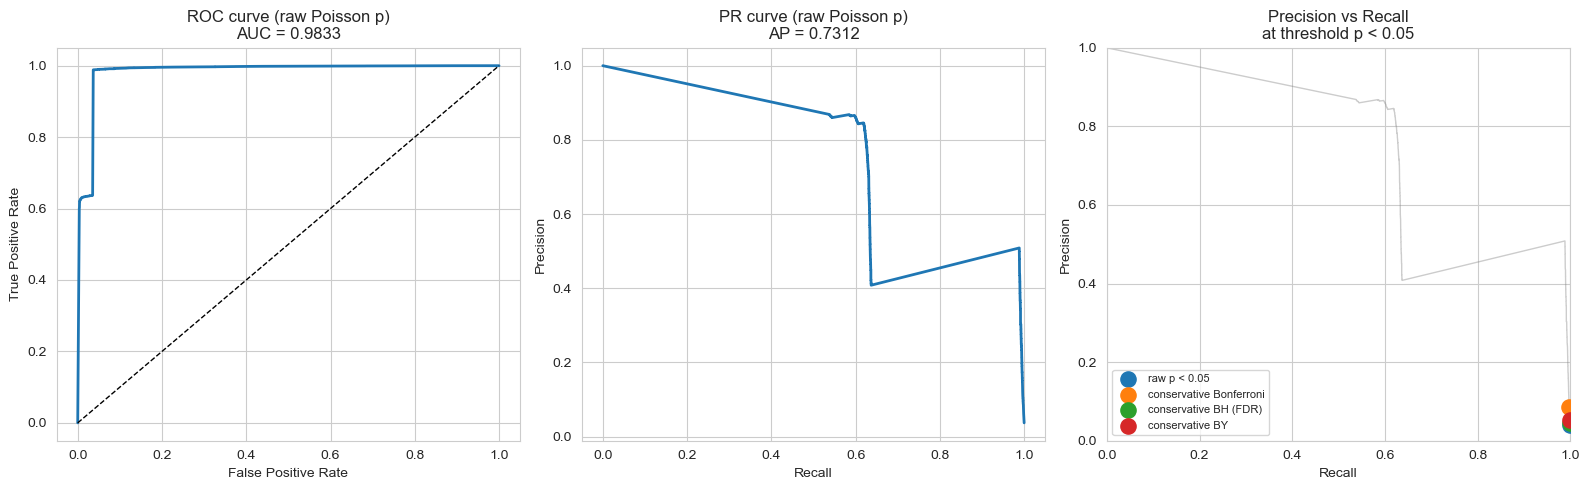

In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

y_true = df["is_mgi_ortholog"].cast(pl.Int8).to_numpy()

# --- Continuous AUC (raw p-value only) ---
# All corrections are monotone transforms of poisson_p → identical ranking → identical AUC.
# Use raw p-value as the continuous discriminator score.
raw_scores = -df["poisson_p"].fill_null(1.0).to_numpy()
roc_auc = roc_auc_score(y_true, raw_scores)
pr_auc  = average_precision_score(y_true, raw_scores)
print(f"Continuous AUC (raw Poisson p, all corrections give same ranking)")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")

# --- Per-correction precision / recall / F1 at threshold α=0.05 ---
correction_cols = {
    "raw p < 0.05":            "poisson_p",
    "conservative Bonferroni": "poisson_p_bonf_conservative",
    "conservative BH (FDR)":   "poisson_p_bh_conservative",
    "conservative BY":         "poisson_p_by_conservative",
}

rows = []
print(f"\n{'Correction':<35} {'Prec':>6} {'Rec':>6} {'F1':>6} {'TP':>8} {'FP':>8} {'FN':>8}")
print("-" * 80)
for label, col in correction_cols.items():
    pred = (df[col].fill_null(1.0) < ALPHA).to_numpy()
    tp = int((pred & (y_true == 1)).sum())
    fp = int((pred & (y_true == 0)).sum())
    fn = int((~pred & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{label:<35} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {tp:>8,} {fp:>8,} {fn:>8,}")
    rows.append({"correction": label, "precision": prec, "recall": rec, "f1": f1})

thresh_df = pd.DataFrame(rows)

# --- Plot: ROC + PR curves (raw p), then per-correction precision/recall scatter ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: ROC curve
fpr, tpr, _ = roc_curve(y_true, raw_scores)
axes[0].plot(fpr, tpr, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC curve (raw Poisson p)\nAUC = {roc_auc:.4f}")

# Panel 2: PR curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, raw_scores)
axes[1].plot(rec_curve, prec_curve, lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR curve (raw Poisson p)\nAP = {pr_auc:.4f}")

# Panel 3: per-correction operating points
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for (_, row), color in zip(thresh_df.iterrows(), colors):
    axes[2].scatter(row["recall"], row["precision"], s=120, color=color,
                    label=row["correction"], zorder=5)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision vs Recall\nat threshold p < 0.05")
axes[2].legend(fontsize=8, loc="lower left")
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
# overlay PR curve for context
axes[2].plot(rec_curve, prec_curve, lw=1, color="grey", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{PREFIX}auc_by_correction.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 2: Score Distributions — What Do False Positives Look Like?

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_80878/323327401.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="set_label", y=col, palette=palette,
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_80878/323327401.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="set_label", y=col, palette=palette,
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_80878/323327401.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="set_label", y=col, palett

Saved ../figures/124_score_distributions.png


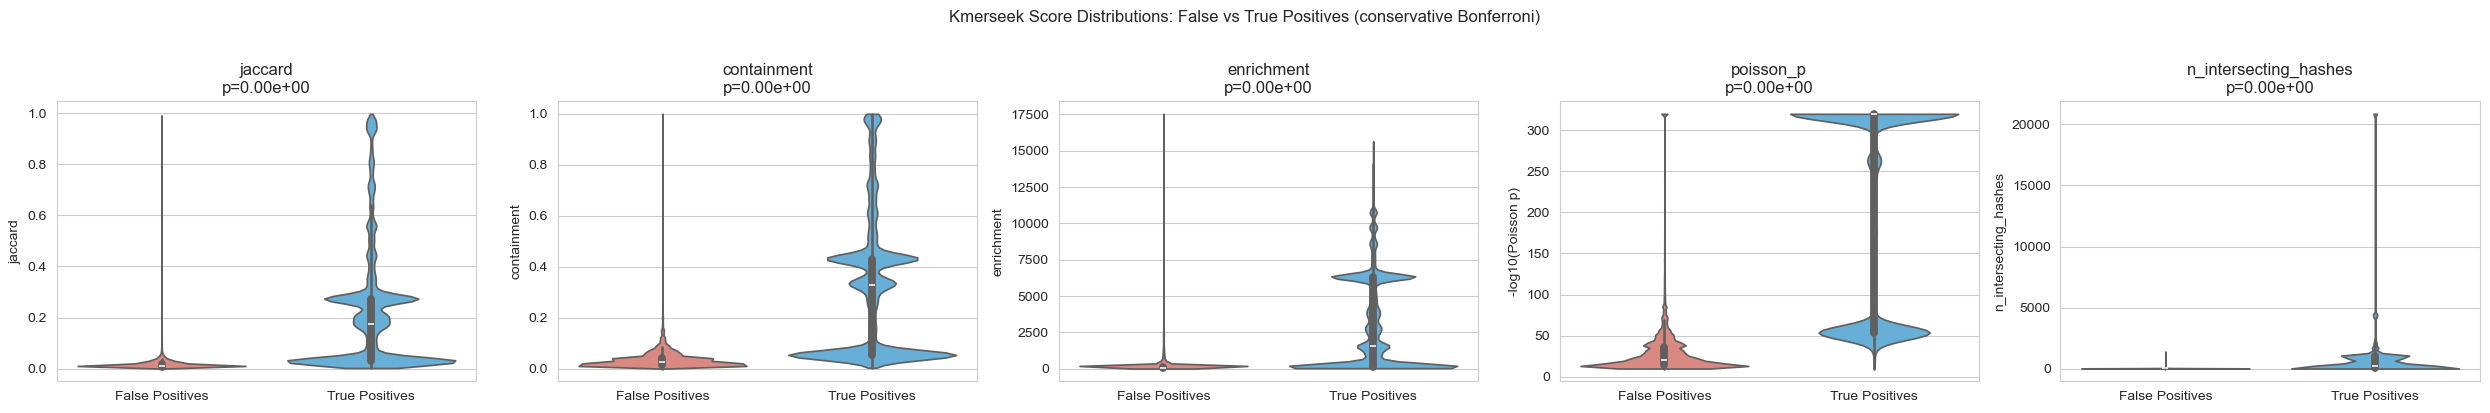

In [7]:
score_cols = ["jaccard", "containment", "enrichment", "poisson_p", "n_intersecting_hashes"]

fp_pd = false_positives.select(score_cols).to_pandas().assign(set_label="False Positives")
tp_pd = true_positives.select(score_cols).to_pandas().assign(set_label="True Positives")
scores_df = pd.concat([fp_pd, tp_pd], ignore_index=True)

palette = {"False Positives": "#E87D72", "True Positives": "#56B4E9"}
order = ["False Positives", "True Positives"]

fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 4))
fig.suptitle("Kmerseek Score Distributions: False vs True Positives (conservative Bonferroni)",
             fontsize=12, y=1.02)

for ax, col in zip(axes, score_cols):
    plot_data = scores_df.dropna(subset=[col]).copy()
    if col == "poisson_p":
        plot_data[col] = -np.log10(plot_data[col].clip(lower=1e-320))
        ylabel = "-log10(Poisson p)"
    else:
        ylabel = col
    sns.violinplot(data=plot_data, x="set_label", y=col, palette=palette,
                   order=order, ax=ax, cut=0, inner="box")
    fp_v = plot_data[plot_data["set_label"] == "False Positives"][col].values
    tp_v = plot_data[plot_data["set_label"] == "True Positives"][col].values
    if len(fp_v) > 1 and len(tp_v) > 1:
        p = mannwhitneyu(fp_v, tp_v, alternative="two-sided")[1]
        ax.set_title(f"{col}\np={p:.2e}")
    else:
        ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.tight_layout()
fig_path = FIGURES_DIR / f"{PREFIX}score_distributions.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## Cell 3: Overlap with OrthoFinder

In [8]:
fp_in_of  = false_positives.filter(pl.col("is_orthofinder"))
fp_not_of = false_positives.filter(~pl.col("is_orthofinder"))
tp_in_of  = true_positives.filter(pl.col("is_orthofinder"))
tp_not_of = true_positives.filter(~pl.col("is_orthofinder"))

print("=== OrthoFinder overlap ===\n")
print(f"False positives also in OrthoFinder: {len(fp_in_of):,} / {len(false_positives):,}"
      f"  ({100*len(fp_in_of)/max(len(false_positives),1):.1f}%)")
print(f"False positives NOT in OrthoFinder:  {len(fp_not_of):,} / {len(false_positives):,}"
      f"  ({100*len(fp_not_of)/max(len(false_positives),1):.1f}%)")
print()
print(f"True positives also in OrthoFinder:  {len(tp_in_of):,} / {len(true_positives):,}"
      f"  ({100*len(tp_in_of)/max(len(true_positives),1):.1f}%)")
print(f"True positives NOT in OrthoFinder:   {len(tp_not_of):,} / {len(true_positives):,}"
      f"  ({100*len(tp_not_of)/max(len(true_positives),1):.1f}%)")

print("\nTop false-positive gene pairs (by Bonferroni p, also in OrthoFinder):")
print(
    fp_in_of
    .select(["human_upper", "mouse_upper", "jaccard", "enrichment", "poisson_p_bonf_conservative"])
    .unique()
    .sort(["poisson_p_bonf_conservative", "enrichment", "jaccard"], descending=[False, True, True])
    .head(10)
)

print("\nTop false-positive gene pairs (by Bonferroni p, NOT in OrthoFinder):")
print(
    fp_not_of
    .select(["human_upper", "mouse_upper", "jaccard", "enrichment", "poisson_p_bonf_conservative"])
    .unique()
    .sort(["poisson_p_bonf_conservative", "enrichment", "jaccard"], descending=[False, True, True])
    .head(10)
)

=== OrthoFinder overlap ===

False positives also in OrthoFinder: 15,670 / 7,292,609  (0.2%)
False positives NOT in OrthoFinder:  7,276,939 / 7,292,609  (99.8%)

True positives also in OrthoFinder:  677,707 / 692,334  (97.9%)
True positives NOT in OrthoFinder:   14,627 / 692,334  (2.1%)

Top false-positive gene pairs (by Bonferroni p, also in OrthoFinder):
shape: (10, 5)
┌─────────────────┬─────────────┬──────────┬──────────────┬─────────────────────────────┐
│ human_upper     ┆ mouse_upper ┆ jaccard  ┆ enrichment   ┆ poisson_p_bonf_conservative │
│ ---             ┆ ---         ┆ ---      ┆ ---          ┆ ---                         │
│ str             ┆ str         ┆ f64      ┆ f64          ┆ f64                         │
╞═════════════════╪═════════════╪══════════╪══════════════╪═════════════════════════════╡
│ ENSG00000256646 ┆ PSMA2       ┆ 0.630332 ┆ 11762.117647 ┆ 0.0                         │
│ STYX            ┆ STYX-PS     ┆ 0.612903 ┆ 10881.959184 ┆ 0.0                       

## Paralog Contamination Analysis

Many false positives may be **cross-species paralog matches**: e.g. human ENO1 hitting mouse ENO2 instead of mouse ENO1. These share high k-mer similarity because they're from the same gene family, but are not true orthologs.

We use OrthoFinder orthogroups as a proxy: if both proteins in a pair belong to the same orthogroup, they are in the same gene family (likely paralogs of the true ortholog pair).

Loading OrthoFinder orthogroups...
Proteins mapped to orthogroups: 262,365

=== Same OrthoFinder orthogroup (proxy for paralog contamination) ===

  FP (all)                            6,033 /  7,292,609  (0.1%)
  FP in OrthoFinder                   6,033 /     15,670  (38.5%)
  FP not in OrthoFinder                   0 /  7,276,939  (0.0%)
  TP (all)                          646,079 /    692,334  (93.3%)
  TP in OrthoFinder                 646,079 /    677,707  (95.3%)


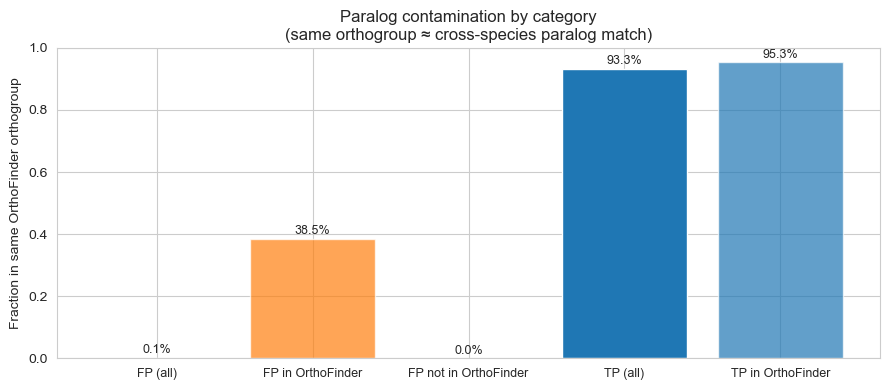

In [9]:
import csv
import matplotlib.pyplot as plt
import numpy as np

ORTHOGROUPS_TSV = Path('/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03/Orthogroups/Orthogroups.tsv')

# Build protein_id (no version) -> orthogroup mapping
print("Loading OrthoFinder orthogroups...")
prot_to_og = {}
with open(ORTHOGROUPS_TSV) as f:
    reader = csv.DictReader(f, delimiter='\t')
    for row in reader:
        og = row['Orthogroup']
        for col in ['gencode.v49.pc_translations', 'gencode.vM38.pc_translations']:
            for prot in row[col].split(','):
                pid = prot.strip().split('|')[0].split('.')[0]  # strip version suffix
                if pid:
                    prot_to_og[pid] = og

print(f"Proteins mapped to orthogroups: {len(prot_to_og):,}")

def _extract_protein_id(name: str) -> str:
    """Extract bare protein ID (no version) from a GENCODE query_name/target_name."""
    return name.split("|")[0].split(".")[0]

# Annotate false_positives and true_positives with same_orthogroup flag
def add_same_orthogroup(df):
    # Use query_name/target_name if human_protein_id/mouse_protein_id aren't present yet
    if "human_protein_id" in df.columns:
        h_ids = df['human_protein_id'].to_list()
        m_ids = df['mouse_protein_id'].to_list()
    else:
        h_ids = [_extract_protein_id(n) for n in df['query_name'].to_list()]
        m_ids = [_extract_protein_id(n) for n in df['target_name'].to_list()]
    og_h = [prot_to_og.get(h) for h in h_ids]
    og_m = [prot_to_og.get(m) for m in m_ids]
    same_og = [
        (oh is not None and oh == om)
        for oh, om in zip(og_h, og_m)
    ]
    return df.with_columns(pl.Series("same_orthogroup", same_og))

false_positives = add_same_orthogroup(false_positives)
true_positives  = add_same_orthogroup(true_positives)

# Refresh stratified subsets
fp_in_of  = false_positives.filter(pl.col("is_orthofinder"))
fp_not_of = false_positives.filter(~pl.col("is_orthofinder"))
tp_in_of  = true_positives.filter(pl.col("is_orthofinder"))
tp_not_of = true_positives.filter(~pl.col("is_orthofinder"))

# Summary statistics — use cat_df to avoid shadowing the global df
print("\n=== Same OrthoFinder orthogroup (proxy for paralog contamination) ===\n")
categories = {
    "FP (all)":              false_positives,
    "FP in OrthoFinder":     fp_in_of,
    "FP not in OrthoFinder": fp_not_of,
    "TP (all)":              true_positives,
    "TP in OrthoFinder":     tp_in_of,
}

for label, cat_df in categories.items():
    n_same  = cat_df['same_orthogroup'].sum()
    n_total = len(cat_df)
    pct     = 100 * n_same / max(n_total, 1)
    print(f"  {label:<30s}  {n_same:>9,} / {n_total:>10,}  ({pct:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(categories.keys())
rates  = [cat_df['same_orthogroup'].mean() for cat_df in categories.values()]
colors = ['#d62728', '#ff7f0e', '#ff7f0e', '#1f77b4', '#1f77b4']
bars   = ax.bar(labels, rates, color=colors, alpha=0.85)
for bar, alpha in zip(bars, [1.0, 0.7, 0.5, 1.0, 0.7]):
    bar.set_alpha(alpha)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.005,
            f"{rate:.1%}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Fraction in same OrthoFinder orthogroup")
ax.set_title("Paralog contamination by category\n(same orthogroup ≈ cross-species paralog match)")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{PREFIX}paralog_contamination.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 4: Extract Ensembl IDs and Map to UniProt

In [10]:
fp_df = ou.prepare_set_df(false_positives, "false_positives")
tp_df = ou.prepare_set_df(true_positives, "true_positives")

print("False positives sample:")
print(fp_df.select(["human_gene_name", "mouse_gene_name", "human_protein_id",
                     "poisson_p", "poisson_p_bonf_conservative"]).head(5))

False positives sample:
shape: (5, 5)
┌─────────────────┬─────────────────┬──────────────────┬────────────┬─────────────────────────────┐
│ human_gene_name ┆ mouse_gene_name ┆ human_protein_id ┆ poisson_p  ┆ poisson_p_bonf_conservative │
│ ---             ┆ ---             ┆ ---              ┆ ---        ┆ ---                         │
│ str             ┆ str             ┆ str              ┆ f64        ┆ f64                         │
╞═════════════════╪═════════════════╪══════════════════╪════════════╪═════════════════════════════╡
│ OR4F5           ┆ Or4c123         ┆ ENSP00000493376  ┆ 1.3716e-22 ┆ 5.6897e-14                  │
│ OR4F5           ┆ Or4e5           ┆ ENSP00000493376  ┆ 1.3716e-22 ┆ 5.6897e-14                  │
│ OR4F5           ┆ Or4e5           ┆ ENSP00000493376  ┆ 1.3716e-22 ┆ 5.6897e-14                  │
│ OR4F5           ┆ Or4e5           ┆ ENSP00000493376  ┆ 1.3716e-22 ┆ 5.6897e-14                  │
│ OR4F5           ┆ Or1e29          ┆ ENSP00000493376  ┆ 1.340

In [11]:
UNIPROT_CACHE_PATH = DATA_DIR / f"{PREFIX}uniprot_id_mapping_cache.json"

# Reuse the cache from notebook 120 if available (it covers the same proteins)
nb120_cache = DATA_DIR / "120_uniprot_id_mapping_cache.json"
if not UNIPROT_CACHE_PATH.exists() and nb120_cache.exists():
    import shutil
    shutil.copy(nb120_cache, UNIPROT_CACHE_PATH)
    print(f"Seeded UniProt cache from notebook 120")

all_ensp = list(set(
    fp_df["human_protein_id"].to_list()
    + tp_df["human_protein_id"].to_list()
))
all_ensp = [x for x in all_ensp if x and x.startswith("ENSP")]
print(f"Unique human ENSP IDs: {len(all_ensp):,}")

uniprot_cache = ou.load_cache(UNIPROT_CACHE_PATH)
print(f"Cache has {len(uniprot_cache):,} entries")

uniprot_cache = ou.batch_map_ensembl_to_uniprot(all_ensp, uniprot_cache)
ou.save_cache(uniprot_cache, UNIPROT_CACHE_PATH)

n_mapped = sum(1 for x in all_ensp if x in uniprot_cache)
print(f"Mapped {n_mapped:,}/{len(all_ensp):,} ({100*n_mapped/max(len(all_ensp),1):.1f}%) ENSP -> UniProt")

fp_df = fp_df.with_columns(
    pl.Series("uniprot_acc", [uniprot_cache.get(p) for p in fp_df["human_protein_id"].to_list()])
)
tp_df = tp_df.with_columns(
    pl.Series("uniprot_acc", [uniprot_cache.get(p) for p in tp_df["human_protein_id"].to_list()])
)
print(f"FP with UniProt: {fp_df['uniprot_acc'].drop_nulls().len():,}/{len(fp_df):,}")
print(f"TP with UniProt: {tp_df['uniprot_acc'].drop_nulls().len():,}/{len(tp_df):,}")

Unique human ENSP IDs: 19,636
Cache has 19,543 entries
Querying 99 new IDs (19,537 cached)
  Batch 1: 99 IDs ... OK (0 mapped)
Mapped 19,537/19,636 (99.5%) ENSP -> UniProt
FP with UniProt: 7,273,989/7,292,609
TP with UniProt: 692,095/692,334


## Cell 5: UniProt Annotations

In [12]:
ANN_CACHE_PATH = DATA_DIR / f"{PREFIX}uniprot_annotations_cache.json"

# Seed from notebook 120 annotation cache if available
nb120_ann_cache = DATA_DIR / "120_uniprot_annotations_cache.json"
if not ANN_CACHE_PATH.exists() and nb120_ann_cache.exists():
    import shutil
    shutil.copy(nb120_ann_cache, ANN_CACHE_PATH)
    print("Seeded annotation cache from notebook 120")

ann_cache = ou.load_cache(ANN_CACHE_PATH)
print(f"Annotation cache has {len(ann_cache):,} entries")

all_acc = list(set(
    [x for x in fp_df["uniprot_acc"].to_list() if x]
    + [x for x in tp_df["uniprot_acc"].to_list() if x]
))

ann_cache = ou.fetch_all_annotations(all_acc, ann_cache, cache_path=ANN_CACHE_PATH)

fp_df = ou.add_annotations(fp_df, ann_cache)
tp_df = ou.add_annotations(tp_df, ann_cache)

print(f"FP membrane: {fp_df['is_membrane'].sum()}/{len(fp_df)}")
print(f"TP membrane: {tp_df['is_membrane'].sum()}/{len(tp_df)}")

Annotation cache has 19,428 entries
Total accessions: 19,422  |  To query: 0
Done. Cache has 19,428 entries.
FP membrane: 719380/7292609
TP membrane: 108416/692334


## Cell 6: MobiDB Disorder

In [13]:
MOBI_CACHE_PATH = DATA_DIR / f"{PREFIX}mobidb_cache.json"

# Seed from notebook 120 if available
nb120_mobi = DATA_DIR / "120_mobidb_cache.json"
if not MOBI_CACHE_PATH.exists() and nb120_mobi.exists():
    import shutil
    shutil.copy(nb120_mobi, MOBI_CACHE_PATH)
    print("Seeded MobiDB cache from notebook 120")

mobi_cache = ou.load_cache(MOBI_CACHE_PATH)
print(f"MobiDB cache has {len(mobi_cache):,} entries")

mobi_cache = ou.fetch_all_mobidb(all_acc, mobi_cache, cache_path=MOBI_CACHE_PATH)

fp_df = ou.add_disorder_fraction(fp_df, mobi_cache)
tp_df = ou.add_disorder_fraction(tp_df, mobi_cache)

fp_dis = fp_df["disorder_fraction"].drop_nulls()
tp_dis = tp_df["disorder_fraction"].drop_nulls()
print(f"FP disorder fraction: median={ou.fmt_median(fp_dis)}  n={len(fp_dis)}")
print(f"TP disorder fraction: median={ou.fmt_median(tp_dis)}  n={len(tp_dis)}")

MobiDB cache has 19,428 entries
To query: 0
Done. MobiDB cache has 19,428 entries.
FP disorder fraction: median=0.400  n=752173
TP disorder fraction: median=0.063  n=27510


## Cell 7: GO Enrichment of False-Positive Human Genes

In [14]:
GO_CACHE = DATA_DIR / f"{PREFIX}go_enrichment_results.csv"

gp = GProfiler(return_dataframe=True)

query_genes = [
    g for g in fp_df["human_gene_name"].unique().drop_nulls().to_list() if g
]
background_genes = [
    g for g in df.filter(pl.col("is_mgi_ortholog"))["human_gene"].unique().drop_nulls().to_list() if g
]

print(f"Query (FP) genes: {len(query_genes):,}")
print(f"Background genes: {len(background_genes):,}")

if GO_CACHE.exists():
    go_results = pd.read_csv(str(GO_CACHE))
    print(f"Loaded {len(go_results):,} GO results from cache")
else:
    try:
        go_results = gp.profile(
            organism="hsapiens",
            query=query_genes,
            background=background_genes,
            sources=["GO:BP", "GO:MF", "GO:CC"],
            significance_threshold_method="fdr",
            user_threshold=0.05,
            no_iea=False,
        )
        go_results.to_csv(str(GO_CACHE), index=False)
        print(f"Enriched GO terms (adj. p < 0.05): {len(go_results):,}")
    except Exception as exc:
        print(f"g:Profiler unavailable ({exc.__class__.__name__}: {exc})")
        go_results = pd.DataFrame(columns=["source", "name", "p_value", "significant"])

if len(go_results) and "significant" in go_results.columns:
    sig = go_results[go_results["significant"]].sort_values("p_value")
    print(f"\nSignificant GO terms: {len(sig):,}")
    if len(sig):
        print(sig[["source", "name", "p_value"]].head(15).to_string())

Query (FP) genes: 19,508
Background genes: 16,623
Loaded 83 GO results from cache

Significant GO terms: 83
   source                                name       p_value
0   GO:MF                             binding  2.811673e-10
1   GO:MF                     protein binding  1.622411e-08
2   GO:MF                  molecular_function  2.780587e-08
3   GO:BP                cell differentiation  7.216789e-08
4   GO:BP      cellular developmental process  7.216789e-08
5   GO:BP               developmental process  8.033119e-08
6   GO:BP  multicellular organism development  1.996099e-06
7   GO:BP    anatomical structure development  2.534253e-06
8   GO:BP                    cellular process  5.557732e-06
9   GO:BP                  biological_process  9.919601e-06
10  GO:CC                      cell periphery  2.330568e-05
11  GO:CC                       cell junction  2.361452e-05
12  GO:BP                  system development  3.474254e-05
13  GO:BP    multicellular organismal process  3.789

## Cell 8: Comparative Visualizations

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_80878/2061136677.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dis_data, x="set_label", y="disorder_fraction",
/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_80878/2061136677.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=len_data, x="set_label", y="seq_length",


Saved ../figures/124_fp_characterization.png


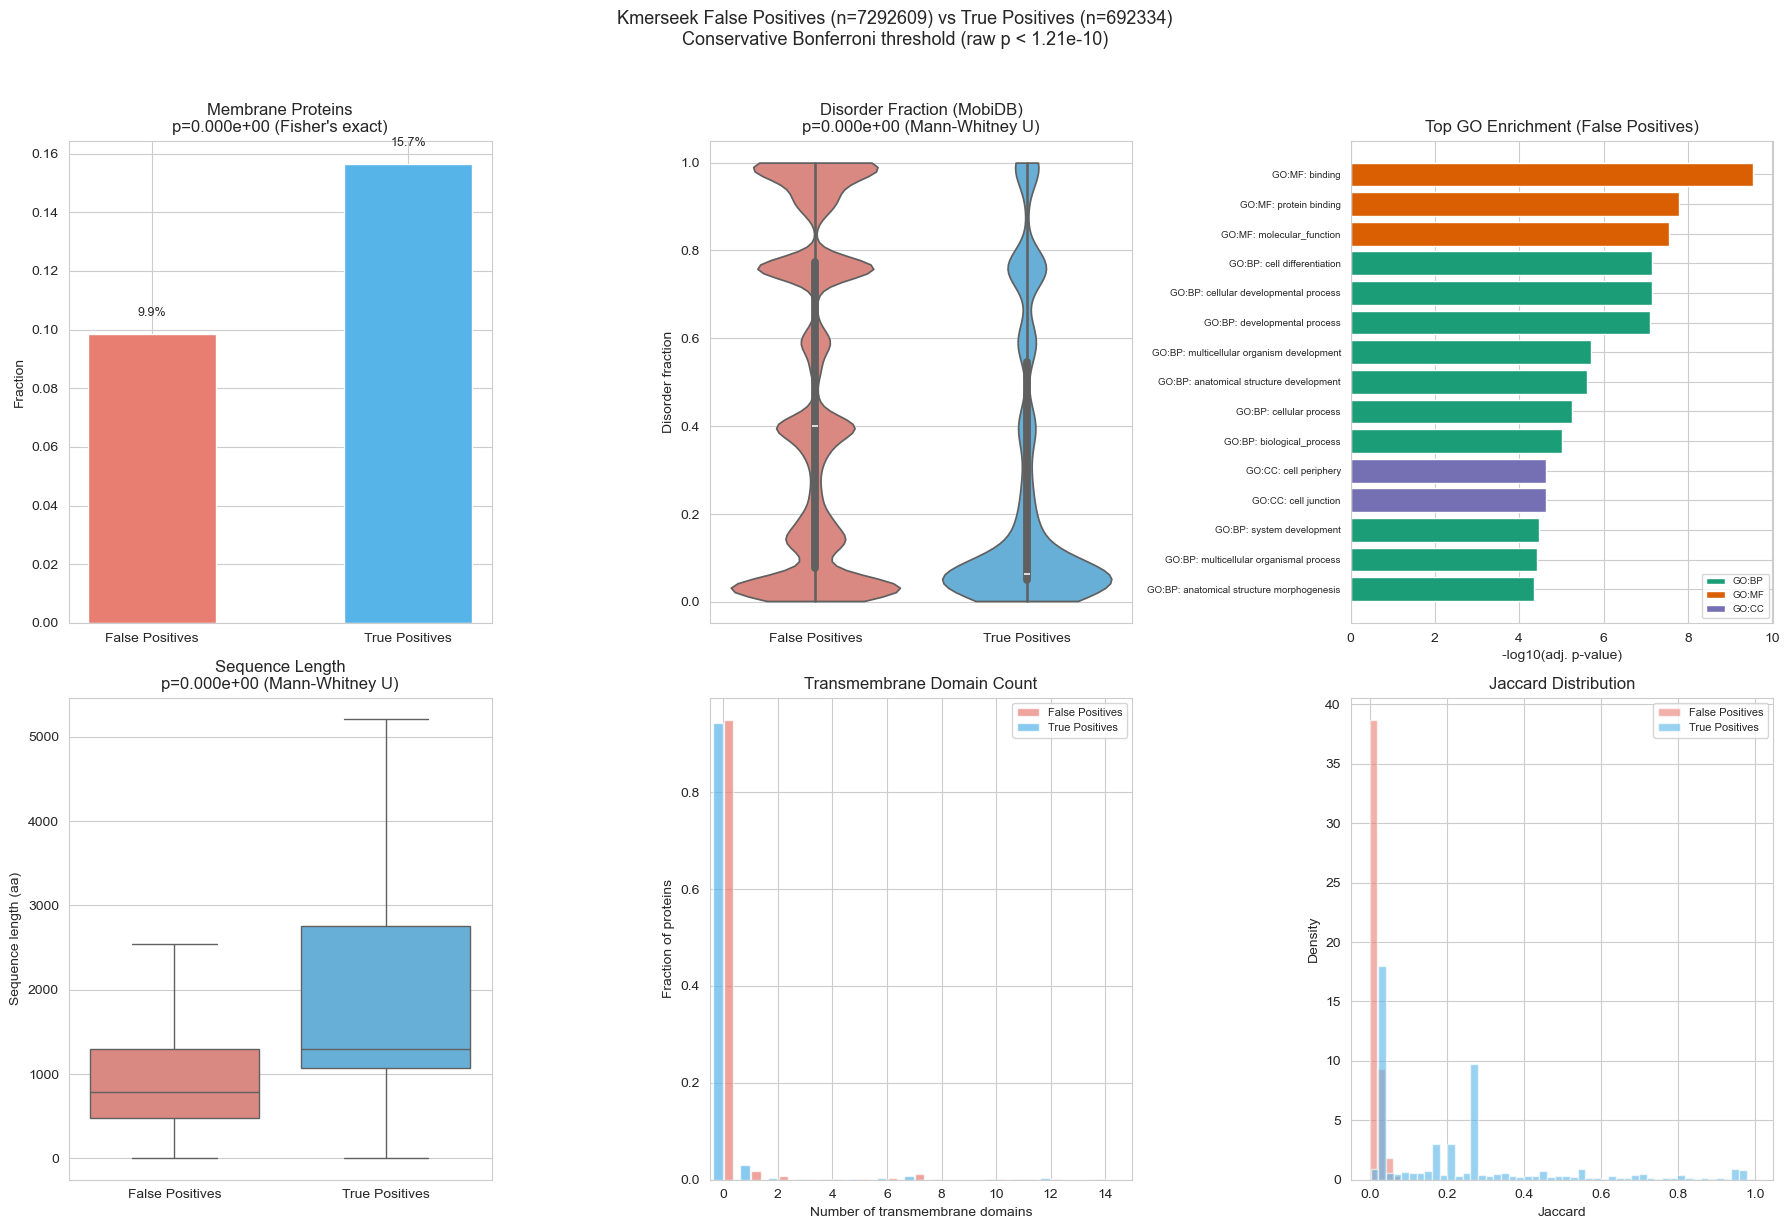

In [15]:
n_fp = len(fp_df)
n_tp = len(tp_df)

combined = pd.concat([
    fp_df.to_pandas().assign(set_label="False Positives"),
    tp_df.to_pandas().assign(set_label="True Positives"),
], ignore_index=True)

palette = {"False Positives": "#E87D72", "True Positives": "#56B4E9"}
order = ["False Positives", "True Positives"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f"Kmerseek False Positives (n={n_fp}) vs True Positives (n={n_tp})\n"
    f"Conservative Bonferroni threshold (raw p < {ou.ALPHA / (N_HUMAN * N_MOUSE):.2e})",
    fontsize=13, y=1.02,
)

# --- Panel 1: Membrane fraction ---
ax = axes[0, 0]
fp_mem = int(fp_df["is_membrane"].sum())
tp_mem = int(tp_df["is_membrane"].sum())
fp_frac = fp_mem / n_fp
tp_frac = tp_mem / n_tp
_, p_mem = fisher_exact([[fp_mem, n_fp - fp_mem], [tp_mem, n_tp - tp_mem]])
bars = ax.bar(order, [fp_frac, tp_frac], color=[palette[k] for k in order], width=0.5)
for bar, val in zip(bars, [fp_frac, tp_frac]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Fraction")
ax.set_title(f"Membrane Proteins\np={p_mem:.3e} (Fisher's exact)")

# --- Panel 2: Disorder fraction violin ---
ax = axes[0, 1]
dis_data = combined.dropna(subset=["disorder_fraction"])
if len(dis_data) > 10:
    sns.violinplot(data=dis_data, x="set_label", y="disorder_fraction",
                   palette=palette, order=order, ax=ax, cut=0, inner="box")
    fp_v = dis_data[dis_data["set_label"] == "False Positives"]["disorder_fraction"].values
    tp_v = dis_data[dis_data["set_label"] == "True Positives"]["disorder_fraction"].values
    p_dis = mannwhitneyu(fp_v, tp_v, alternative="two-sided")[1] if (len(fp_v) > 1 and len(tp_v) > 1) else float("nan")
    ax.set_title(f"Disorder Fraction (MobiDB)\np={p_dis:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Disorder fraction")
else:
    ax.text(0.5, 0.5, "No MobiDB data", ha="center", va="center", transform=ax.transAxes)

# --- Panel 3: Top GO terms (FP) ---
ax = axes[0, 2]
sig_go = (
    go_results[go_results["significant"]].sort_values("p_value").head(15).copy()
    if len(go_results) > 0 and "significant" in go_results.columns
    else pd.DataFrame()
)
if len(sig_go) > 0:
    source_colors = {"GO:BP": "#1B9E77", "GO:MF": "#D95F02", "GO:CC": "#7570B3"}
    bar_colors = [source_colors.get(s, "grey") for s in sig_go["source"]]
    ax.barh(range(len(sig_go)), -np.log10(sig_go["p_value"]), color=bar_colors)
    ax.set_yticks(range(len(sig_go)))
    ax.set_yticklabels(
        [f"{row.source}: {row['name'][:35]}" for _, row in sig_go.iterrows()], fontsize=7
    )
    ax.invert_yaxis()
    ax.set_xlabel("-log10(adj. p-value)")
    ax.set_title("Top GO Enrichment (False Positives)")
    from matplotlib.patches import Patch
    ax.legend(
        handles=[Patch(facecolor=c, label=s) for s, c in source_colors.items()],
        fontsize=7, loc="lower right",
    )
else:
    ax.text(0.5, 0.5, "No significant GO terms", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Top GO Enrichment (False Positives)")

# --- Panel 4: Sequence length ---
ax = axes[1, 0]
len_data = combined.dropna(subset=["seq_length"])
if len(len_data) > 10:
    sns.boxplot(data=len_data, x="set_label", y="seq_length",
                palette=palette, order=order, ax=ax, showfliers=False)
    fp_v = len_data[len_data["set_label"] == "False Positives"]["seq_length"].values
    tp_v = len_data[len_data["set_label"] == "True Positives"]["seq_length"].values
    p_len = mannwhitneyu(fp_v, tp_v, alternative="two-sided")[1] if (len(fp_v) > 1 and len(tp_v) > 1) else float("nan")
    ax.set_title(f"Sequence Length\np={p_len:.3e} (Mann-Whitney U)")
    ax.set_xlabel("")
    ax.set_ylabel("Sequence length (aa)")
else:
    ax.text(0.5, 0.5, "No length data", ha="center", va="center", transform=ax.transAxes)

# --- Panel 5: Transmembrane domain count ---
ax = axes[1, 1]
tm_data = combined.dropna(subset=["n_transmembrane"])
if len(tm_data) > 0:
    for label, color in palette.items():
        sub = tm_data[tm_data["set_label"] == label]
        counts = sub["n_transmembrane"].value_counts().sort_index()
        offset = 0.2 if label == "False Positives" else -0.2
        ax.bar(
            counts.index + offset, counts.values / len(sub),
            alpha=0.7, color=color, label=label, width=0.35,
        )
    ax.set_xlabel("Number of transmembrane domains")
    ax.set_ylabel("Fraction of proteins")
    ax.set_title("Transmembrane Domain Count")
    ax.set_xlim(-0.5, 15)
    ax.legend(fontsize=8)

# --- Panel 6: Jaccard score density ---
ax = axes[1, 2]
for label, color in palette.items():
    sub = combined[combined["set_label"] == label]["jaccard"].dropna()
    ax.hist(sub, bins=50, alpha=0.6, color=color, label=label, density=True)
ax.set_xlabel("Jaccard")
ax.set_ylabel("Density")
ax.set_title("Jaccard Distribution")
ax.legend(fontsize=8)

plt.tight_layout()
fig_path = FIGURES_DIR / f"{PREFIX}fp_characterization.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## Cell 9: Summary Statistics Table

In [16]:
fp_pd = fp_df.to_pandas()
tp_pd = tp_df.to_pandas()

fp_mem_n = int(fp_pd["is_membrane"].sum())
tp_mem_n = int(tp_pd["is_membrane"].sum())
_, p_mem = fisher_exact([[fp_mem_n, n_fp - fp_mem_n], [tp_mem_n, n_tp - tp_mem_n]])

fp_dis_n = int(fp_pd["has_disordered_regions"].sum())
tp_dis_n = int(tp_pd["has_disordered_regions"].sum())
_, p_dis_b = fisher_exact([[fp_dis_n, n_fp - fp_dis_n], [tp_dis_n, n_tp - tp_dis_n]])

summary_rows = [
    {
        "Feature": "Count (pairs)",
        f"False Positives (n={n_fp})": f"{n_fp:,}",
        f"True Positives (n={n_tp})": f"{n_tp:,}",
        "p-value": "—", "Test": "—",
    },
    {
        "Feature": "% membrane proteins",
        f"False Positives (n={n_fp})": f"{100*fp_mem_n/n_fp:.1f}%",
        f"True Positives (n={n_tp})": f"{100*tp_mem_n/n_tp:.1f}%",
        "p-value": f"{p_mem:.3e}", "Test": "Fisher's exact",
    },
    {
        "Feature": "% with disordered regions (UniProt)",
        f"False Positives (n={n_fp})": f"{100*fp_dis_n/n_fp:.1f}%",
        f"True Positives (n={n_tp})": f"{100*tp_dis_n/n_tp:.1f}%",
        "p-value": f"{p_dis_b:.3e}", "Test": "Fisher's exact",
    },
    {
        "Feature": "Median disorder fraction (MobiDB)",
        f"False Positives (n={n_fp})": ou.fmt_median(fp_df["disorder_fraction"].drop_nulls()),
        f"True Positives (n={n_tp})": ou.fmt_median(tp_df["disorder_fraction"].drop_nulls()),
        "p-value": f"{ou.safe_mwu(fp_pd['disorder_fraction'].dropna().values, tp_pd['disorder_fraction'].dropna().values):.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median sequence length (aa)",
        f"False Positives (n={n_fp})": f"{np.median(fp_pd['seq_length'].dropna().values):.0f}" if len(fp_pd['seq_length'].dropna()) else "N/A",
        f"True Positives (n={n_tp})": f"{np.median(tp_pd['seq_length'].dropna().values):.0f}" if len(tp_pd['seq_length'].dropna()) else "N/A",
        "p-value": f"{ou.safe_mwu(fp_pd['seq_length'].dropna().values, tp_pd['seq_length'].dropna().values):.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median Jaccard",
        f"False Positives (n={n_fp})": f"{fp_pd['jaccard'].median():.4f}",
        f"True Positives (n={n_tp})": f"{tp_pd['jaccard'].median():.4f}",
        "p-value": f"{ou.safe_mwu(fp_pd['jaccard'].dropna().values, tp_pd['jaccard'].dropna().values):.3e}",
        "Test": "Mann-Whitney U",
    },
    {
        "Feature": "Median enrichment",
        f"False Positives (n={n_fp})": f"{fp_pd['enrichment'].median():.4f}",
        f"True Positives (n={n_tp})": f"{tp_pd['enrichment'].median():.4f}",
        "p-value": f"{ou.safe_mwu(fp_pd['enrichment'].dropna().values, tp_pd['enrichment'].dropna().values):.3e}",
        "Test": "Mann-Whitney U",
    },
]

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_path = DATA_DIR / f"{PREFIX}summary_statistics.csv"
summary_df.to_csv(str(summary_path), index=False)
print(f"\nSaved to {summary_path}")

                            Feature False Positives (n=7292609) True Positives (n=692334)   p-value           Test
                      Count (pairs)                   7,292,609                   692,334         —              —
                % membrane proteins                        9.9%                     15.7% 0.000e+00 Fisher's exact
% with disordered regions (UniProt)                       89.4%                     91.9% 0.000e+00 Fisher's exact
  Median disorder fraction (MobiDB)                       0.400                     0.063 0.000e+00 Mann-Whitney U
        Median sequence length (aa)                         786                      1301 0.000e+00 Mann-Whitney U
                     Median Jaccard                      0.0110                    0.1740 0.000e+00 Mann-Whitney U
                  Median enrichment                     65.5361                 1554.2045 0.000e+00 Mann-Whitney U

Saved to /Users/olga/data/gencode/results-human-mouse-orthologs/124_summary_sta

## Cell 10: Save Annotated Results

In [17]:
annotation_cols = [
    "human_gene_name", "mouse_gene_name", "human_protein_id", "human_gene_id",
    "uniprot_acc", "set_label",
    "jaccard", "containment", "enrichment", "n_intersecting_hashes",
    "poisson_p", "poisson_p_bonf_conservative",
    "is_orthofinder", "is_mgi_ortholog",
    "seq_length", "subcellular_location", "is_membrane", "is_secreted", "is_nuclear",
    "n_transmembrane", "n_disordered_regions", "has_disordered_regions",
    "disorder_fraction", "keywords",
]

combined_ann = pl.concat([
    fp_df.select([c for c in annotation_cols if c in fp_df.columns]),
    tp_df.select([c for c in annotation_cols if c in tp_df.columns]),
])

ann_path = DATA_DIR / f"{PREFIX}annotation_results.csv"
combined_ann.write_csv(str(ann_path))
print(f"Saved {len(combined_ann):,} rows to {ann_path}")

fp_path = DATA_DIR / f"{PREFIX}false_positive_pairs.csv"
fp_df.select([c for c in annotation_cols if c in fp_df.columns]).write_csv(str(fp_path))
print(f"Saved {len(fp_df):,} false-positive pairs to {fp_path}")

Saved 7,984,943 rows to /Users/olga/data/gencode/results-human-mouse-orthologs/124_annotation_results.csv
Saved 7,292,609 false-positive pairs to /Users/olga/data/gencode/results-human-mouse-orthologs/124_false_positive_pairs.csv
